## Load Graph from .txt file

In [12]:
import numpy as np
from collections import defaultdict

file_path = r"E:\SC4052 Cloud Computing\Cloud Computing Assignment 2\web-Google_10k\web-Google_10k.txt"

out_links = defaultdict(list)
nodes = set()

with open(file_path, 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        src, dst = map(int, line.strip().split())
        out_links[src].append(dst)
        nodes.add(src)
        nodes.add(dst)

nodes = list(nodes)
n = len(nodes)

# Map node IDs to indices
node_to_idx = {node: i for i, node in enumerate(nodes)}

## Build out-degree for each node

In [13]:
out_degree = np.zeros(n)
num_dangling_nodes = 0

for node in nodes:
    idx = node_to_idx[node]
    out_degree[idx] = len(out_links[node])
    if len(out_links[node]) == 0:
        num_dangling_nodes += 1

# Number of dangling nodes
print(f"Number of dangling nodes: {num_dangling_nodes}")
print(f"Number of nodes: {n}")

Number of dangling nodes: 1235
Number of nodes: 10000


## PageRank Iterative Algorithm

In [14]:
import numpy as np

def compute_pagerank(
    outgoing_links,        # dict: node -> list of nodes it points to
    node_to_index,         # mapping: node_id -> index in array
    out_degree_array,      # number of outgoing links per node
    num_sites,             # total number of nodes
    teleport_prob=0.15,    # p
    max_iterations=100,
    tolerance=1e-6
):
    """
    Computes PageRank using iterative method from lecture slides (taking into account dangling nodes).

    Corresponds to:
    ranks_new = (1 - p) * M * ranks + p * (1/n) * 1
    """

    # Step 0: Initialize ranks uniformly
    current_ranks = np.ones(num_sites) / num_sites

    l1_diffs = [] # Store l1_diffs per iteration

    for iteration in range(max_iterations):
        # Step 1: Initialize next iteration ranks to zero
        next_ranks = np.zeros(num_sites)

        # Step 2: Apply M * ranks (link-following step)
        # Each node distributes its rank to its neighbors
        for source_node in outgoing_links:
            source_index = node_to_index[source_node]
            if out_degree_array[source_index] == 0: # If no outgoing links -> skip for now (handled later)
                continue

            share_per_neighbor = current_ranks[source_index] / out_degree_array[source_index] # "share" = how much rank this node gives to EACH neighbor, equivalent to dividing by number of outgoing links

            for destination_node in outgoing_links[source_node]: # Distribute this share to all neighbors
                destination_index = node_to_index[destination_node]
                next_ranks[destination_index] += share_per_neighbor

        # Step 3: Handle Dangling Nodes (nodes with NO outgoing links)
        # Their rank would "disappear", so instead we redistribute it uniformly
        dangling_rank_sum = 0.0
        for i in range(num_sites):
            if out_degree_array[i] == 0:
                dangling_rank_sum += current_ranks[i]
        
        next_ranks += dangling_rank_sum / num_sites  # Redistribute dangling mass equally to all nodes

        # Step 4: Apply teleportation
        # Adds: p * (1/n) * 1
        # Final equation: next_ranks = (1 - p) * next_ranks + p / n
        next_ranks = (1 - teleport_prob) * next_ranks + teleport_prob / num_sites

        # Step 5: Check convergence, Using L1 norm (sum of absolute differences)
        diff = np.linalg.norm(next_ranks - current_ranks, 1)
        l1_diffs.append(diff)   # Store diffs

        if diff < tolerance:
            print(f"Converged in {iteration} iterations")
            break

        current_ranks = next_ranks

    return current_ranks, l1_diffs

r_iter, l1_diffs = compute_pagerank(outgoing_links=out_links, node_to_index=node_to_idx, out_degree_array=out_degree, num_sites=n, teleport_prob=0.15, max_iterations=100, tolerance=1e-6)


Converged in 58 iterations


### l1_diffs against iteration

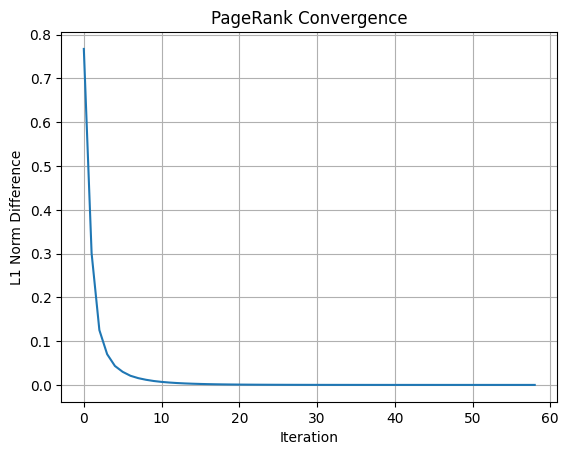

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(len(l1_diffs)), l1_diffs)
plt.xlabel("Iteration")
plt.ylabel("L1 Norm Difference")
plt.title("PageRank Convergence")
plt.grid()
plt.show()

## Closed Form Solution

### Build M

In [5]:
import numpy as np

# Initialize dense matrix
M = np.zeros((n, n))

# Compute out-degree
out_degree = {node: len(out_links[node]) for node in nodes}

# Fill matrix
for src in out_links:
    j = node_to_idx[src]

    if out_degree[src] == 0:
        continue  # dangling handled later

    prob = 1 / out_degree[src]

    for dst in out_links[src]:
        i = node_to_idx[dst]
        M[i, j] = prob

# Handle dangling nodes
for node in nodes:
    j = node_to_idx[node]

    if out_degree[node] == 0:
        # distribute uniformly
        M[:, j] = 1 / n

### Compute closed form

In [6]:
# r =p(I - (1-p)M)^(-1) x (1/n)1

p = 0.15

I = np.eye(n)
one = np.ones((n, 1)) / n

# Compute inverse
A = I - (1 - p) * M
r_closed = p * np.linalg.inv(A) @ one

# Flatten to 1D
r_closed = r_closed.flatten()

r_closed = r_closed / r_closed.sum() # Normalize incase of floating point error or matrix conditioning

# Comparing Closed Form & Iterative Results

In [ ]:
# Check L1 norm (sum of absolute differences element-wise)
difference = np.linalg.norm(r_iter - r_closed, 1)
print("Difference:", difference)

Difference: 2.7069680743948246e-06


In [ ]:
# Check ordering of the ranks ( Too Strict )
# ranking_iter = np.argsort(-r_iter) # Ranking = indices sorted by descending score:
# ranking_closed = np.argsort(-r_closed)
# print(np.array_equal(ranking_iter, ranking_closed))

from scipy.stats import spearmanr

correlation, _ = spearmanr(r_iter, r_closed)
print("Spearman correlation:", correlation)

Spearman correlation: 0.9999985748849187
